In [1]:
import pandas as pd

In [10]:
df = pd.read_csv('/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/weight_tuning_all/pairwise_scores.csv')
df.head()

,source_file,dataset,scene_id,frame_pair_idx,f1,miou,confidence_current,obj_count_t,obj_count_prev,both_empty,confidence_tuned
0,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,1,0.911565,0.583476,0.711522,78,69,False,0.744184
1,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,2,0.939024,0.591160,0.725553,86,78,False,0.760113
2,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,3,0.944444,0.612324,0.742958,94,86,False,0.776072
3,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,4,0.944162,0.636585,0.760451,103,94,False,0.791242
4,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,5,0.980583,0.675887,0.800213,103,103,False,0.830776


In [6]:
nus_df = df[df['dataset'] == 'nuscenes_mini']
nus_df0 = nus_df[nus_df['scene_id'] == "cc8c0bf57f984915a77078b10eb33198"]
nus_df0

,source_file,dataset,scene_id,frame_pair_idx,f1,miou,confidence_current,obj_count_t,obj_count_prev,both_empty,confidence_tuned
0,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,1,0.911565,0.583476,0.711522,78,69,False,0.744184
1,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,2,0.939024,0.591160,0.725553,86,78,False,0.760113
2,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,3,0.944444,0.612324,0.742958,94,86,False,0.776072
3,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,4,0.944162,0.636585,0.760451,103,94,False,0.791242
4,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,5,0.980583,0.675887,0.800213,103,103,False,0.830776
5,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,6,0.948357,0.682040,0.793449,110,103,False,0.820245
6,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,7,0.956140,0.670675,0.788363,118,110,False,0.817037
7,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,8,0.974790,0.709818,0.821467,120,118,False,0.848147
8,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,9,0.967213,0.719726,0.825317,124,120,False,0.850265
9,unified_nuscenes_mini.json,nuscenes_mini,cc8c0bf57f984915a77078b10eb33198,10,0.972112,0.722187,0.828717,127,124,False,0.853909


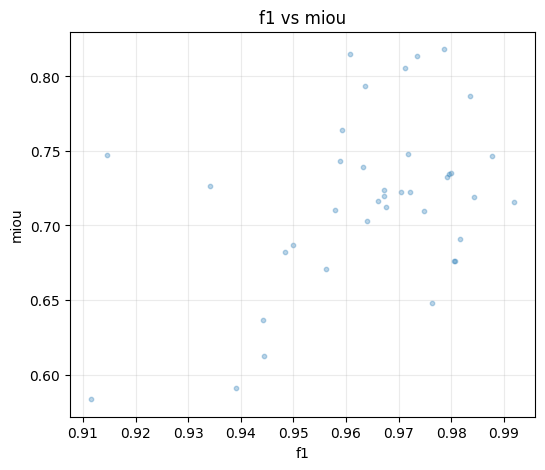

In [7]:
miou = nus_df0['miou']
f1 = nus_df0['f1']
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(f1, miou, s=10, alpha=0.3)
plt.xlabel("f1")
plt.ylabel("miou")
plt.title("f1 vs miou")
plt.grid(alpha=0.25)
plt.show()

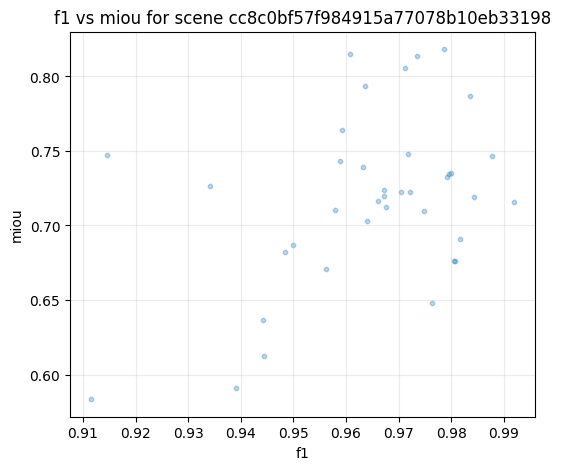

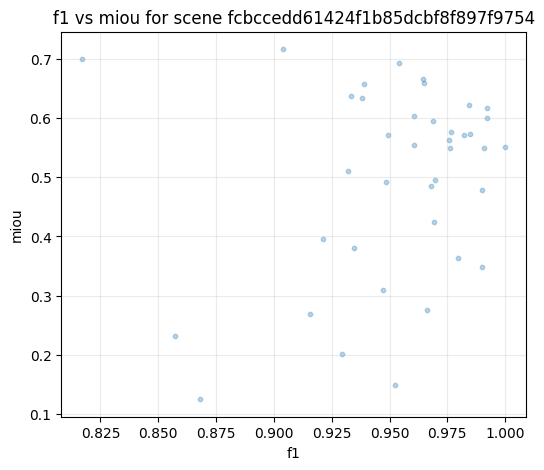

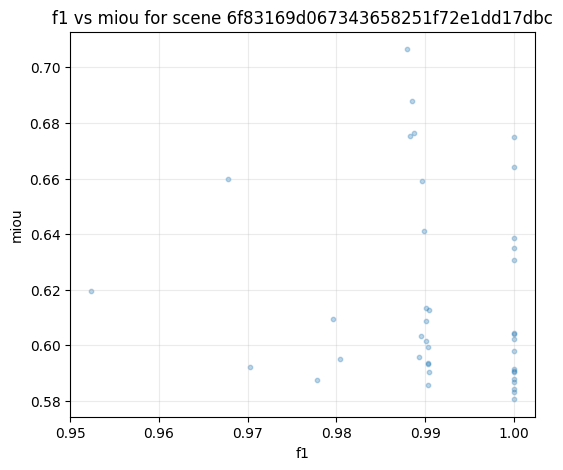

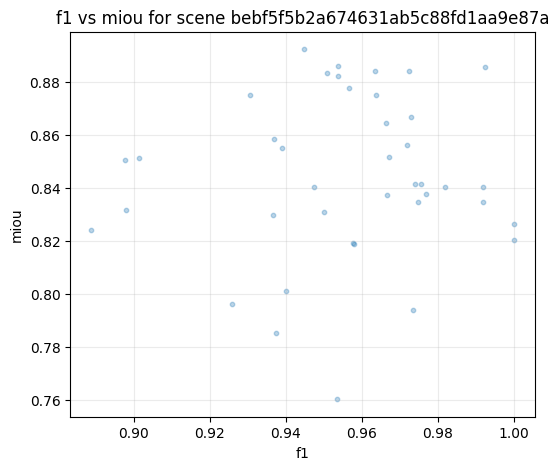

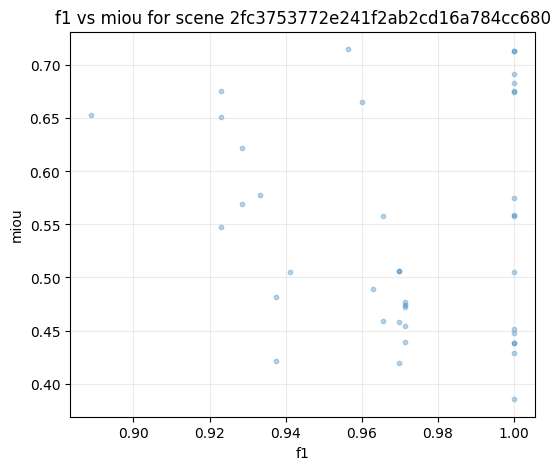

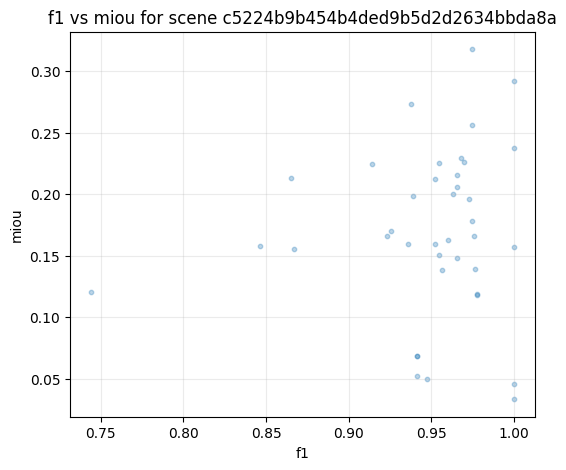

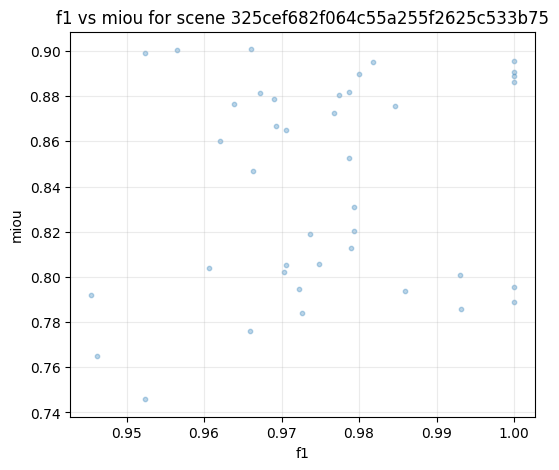

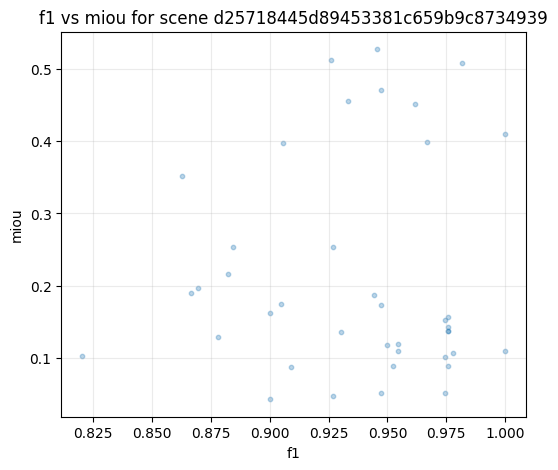

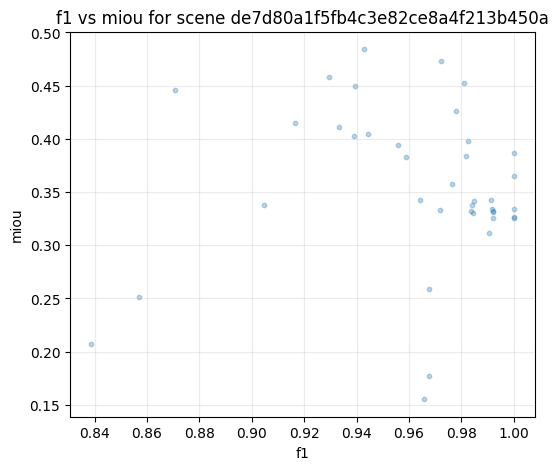

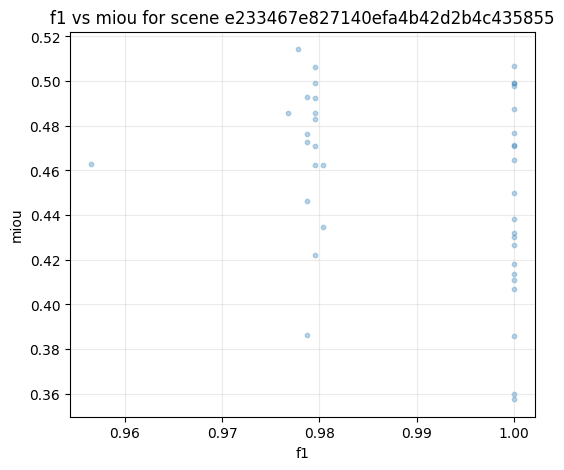

In [8]:
sc_id = nus_df["scene_id"].unique()
for s in sc_id:
    nus_df = df[df['dataset'] == 'nuscenes_mini']
    nus_df0 = nus_df[nus_df['scene_id'] == s]
    miou = nus_df0['miou']
    f1 = nus_df0['f1']
    plt.figure(figsize=(6,5))
    plt.scatter(f1, miou, s=10, alpha=0.3)
    plt.xlabel("f1")
    plt.ylabel("miou")
    plt.title(f"f1 vs miou for scene {s}")
    plt.grid(alpha=0.25)
    plt.show()


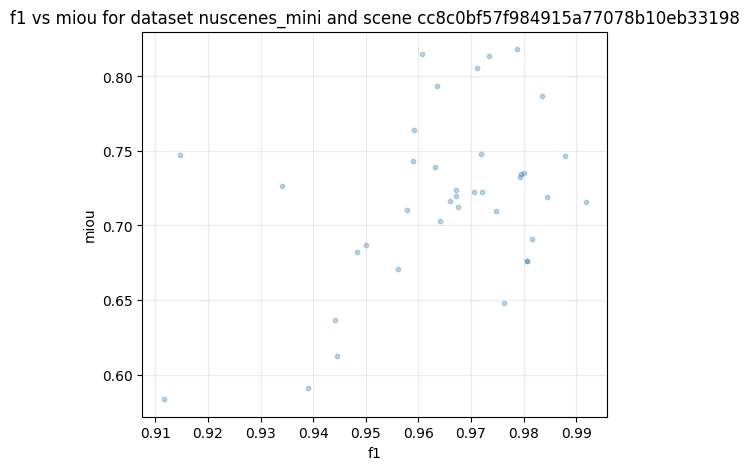

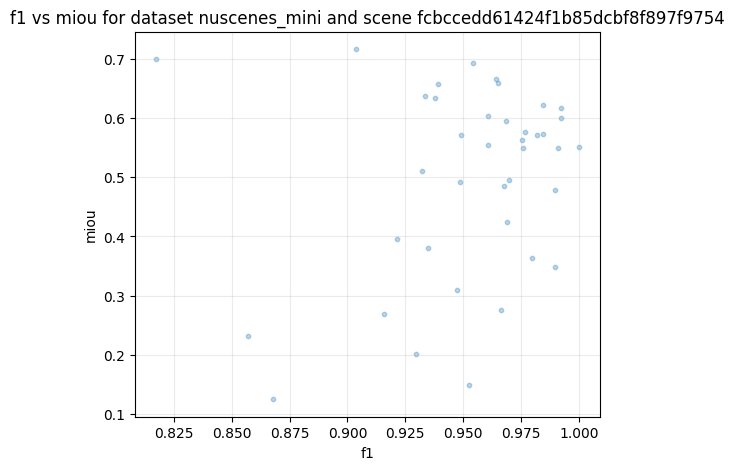

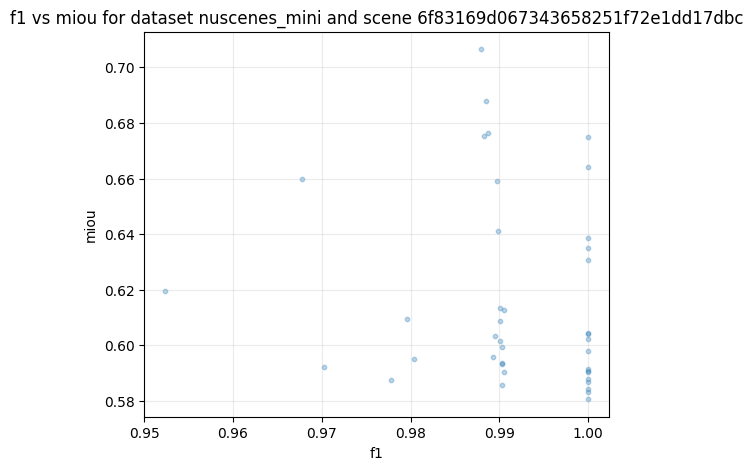

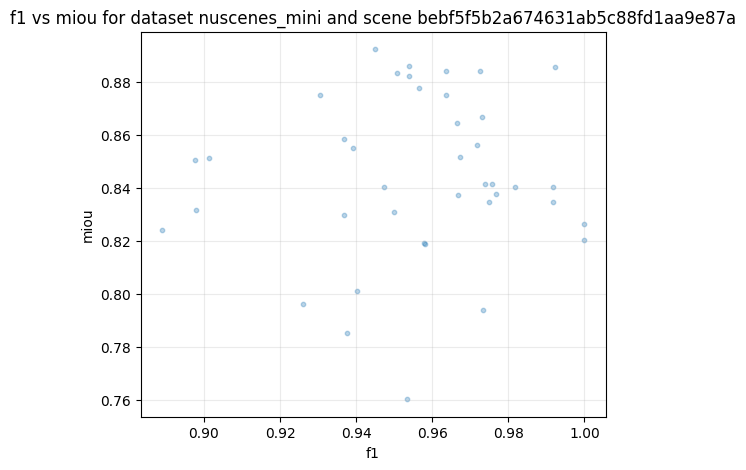

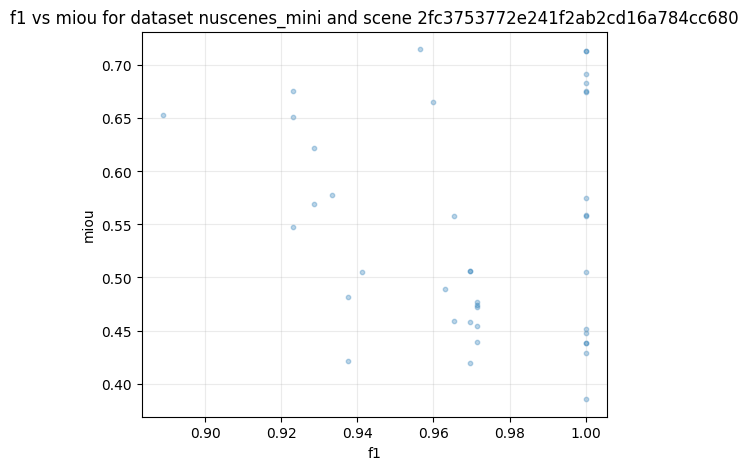

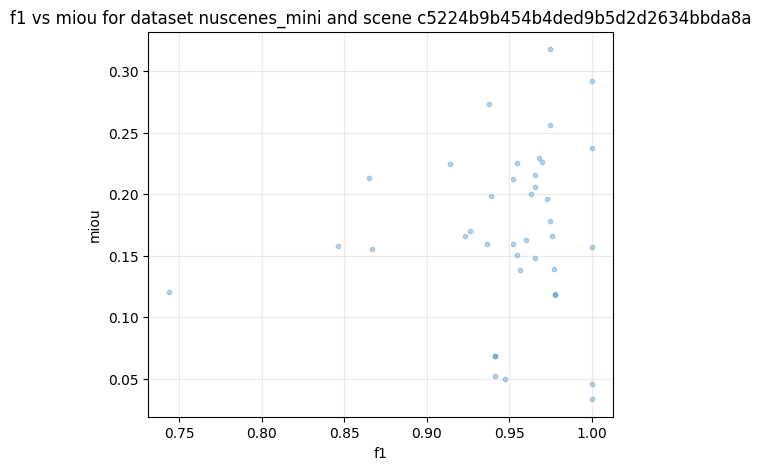

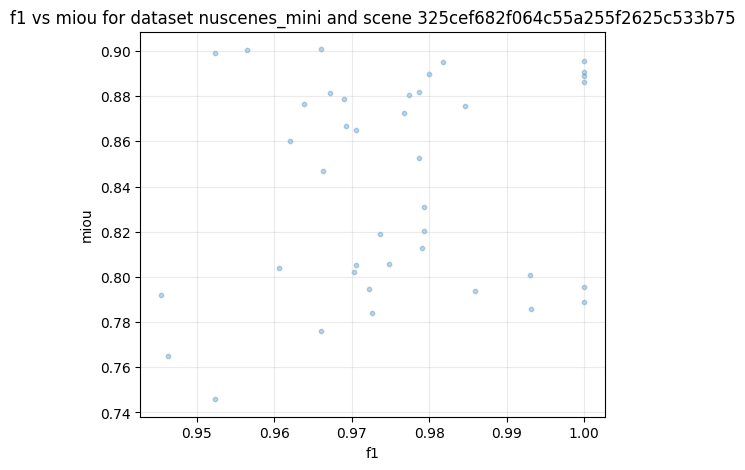

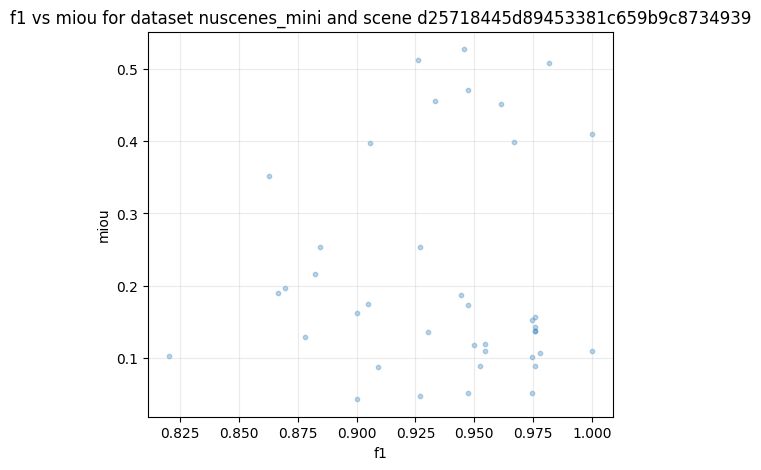

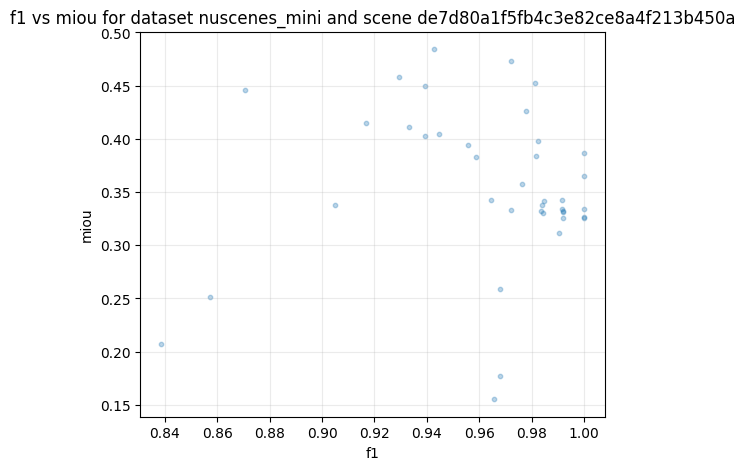

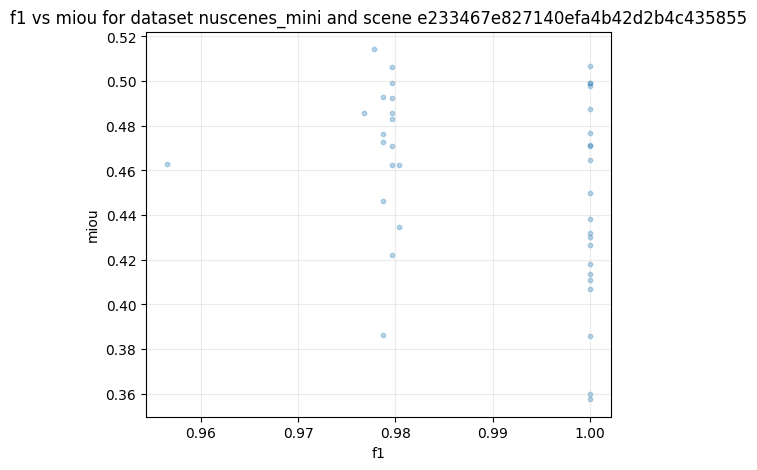

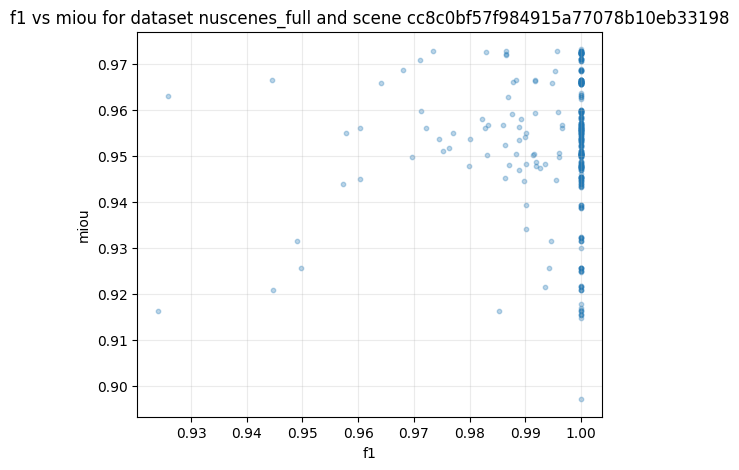

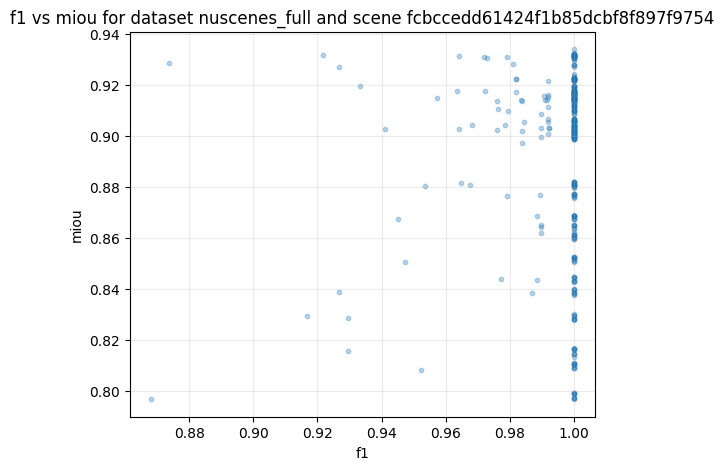

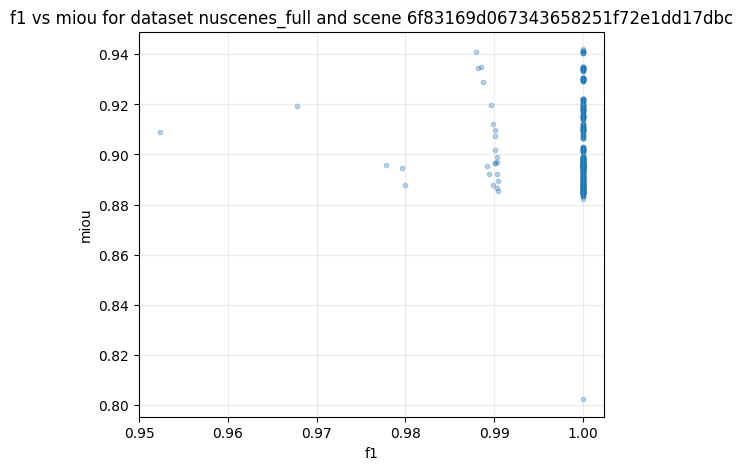

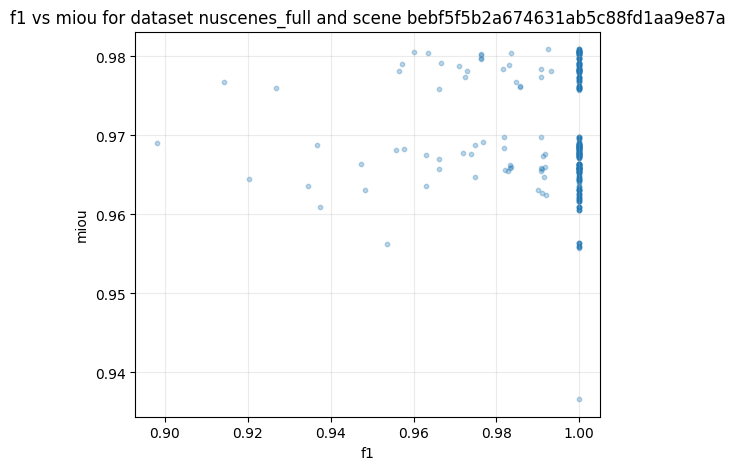

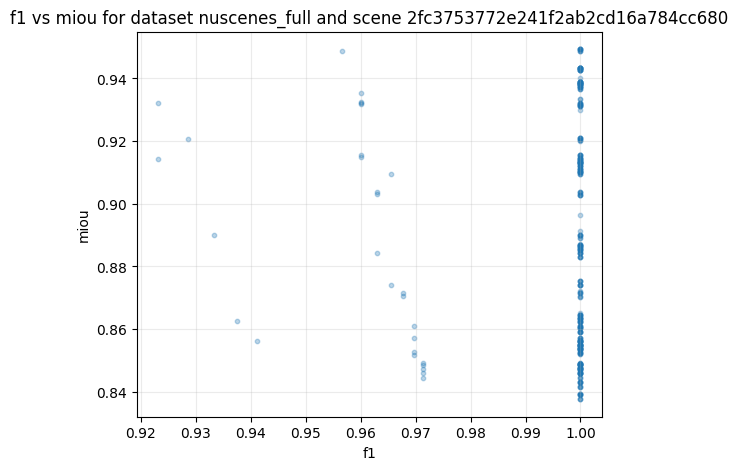

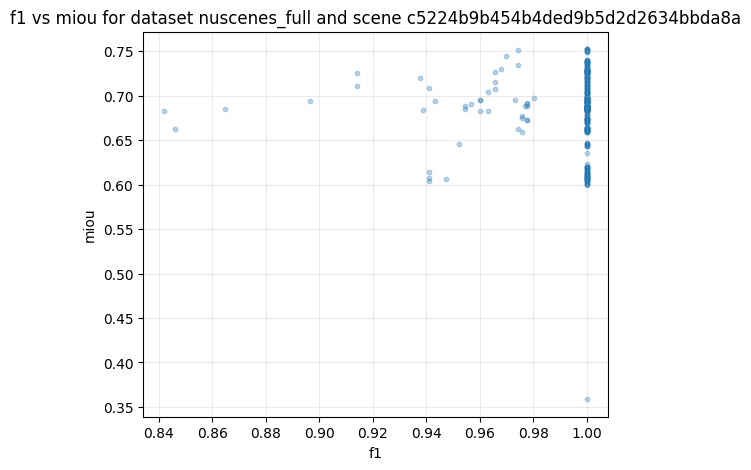

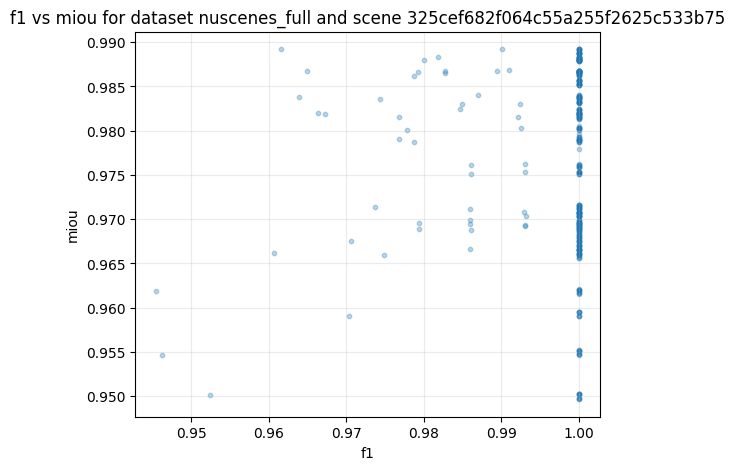

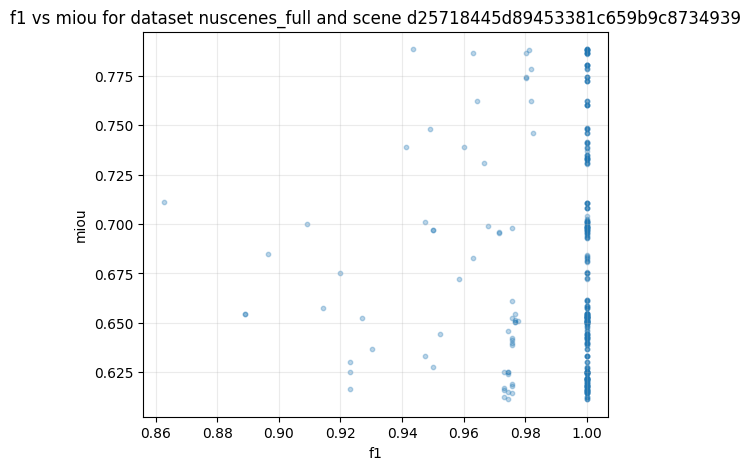

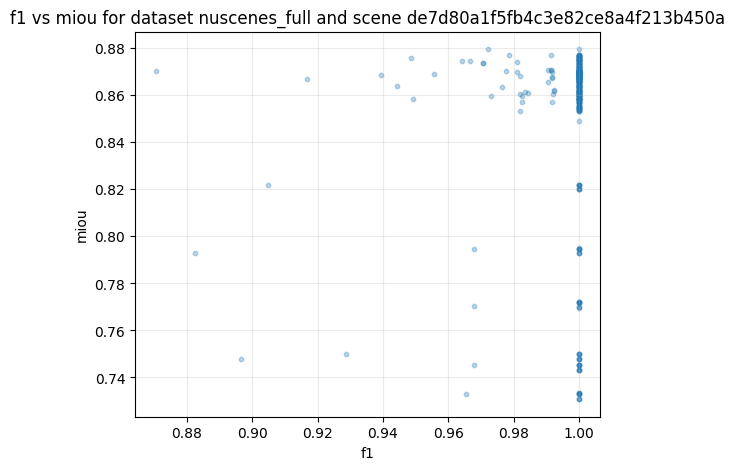

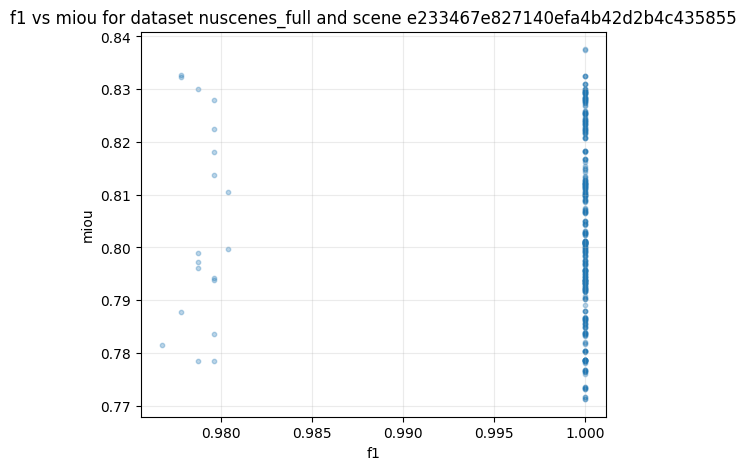

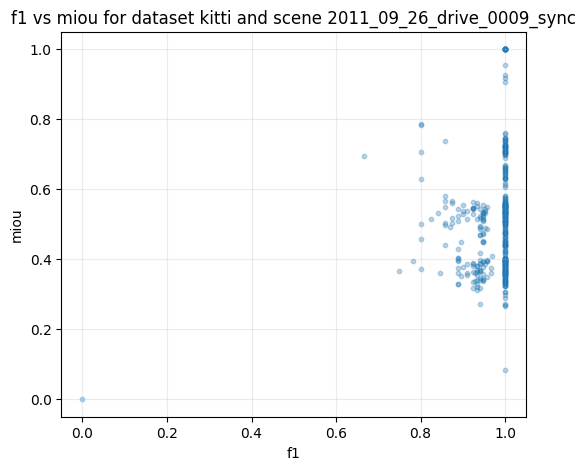

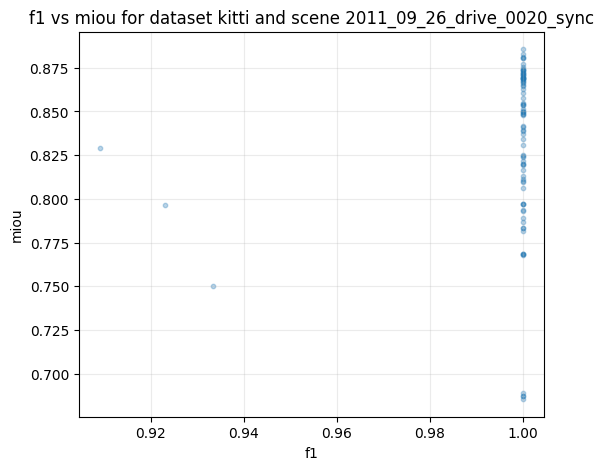

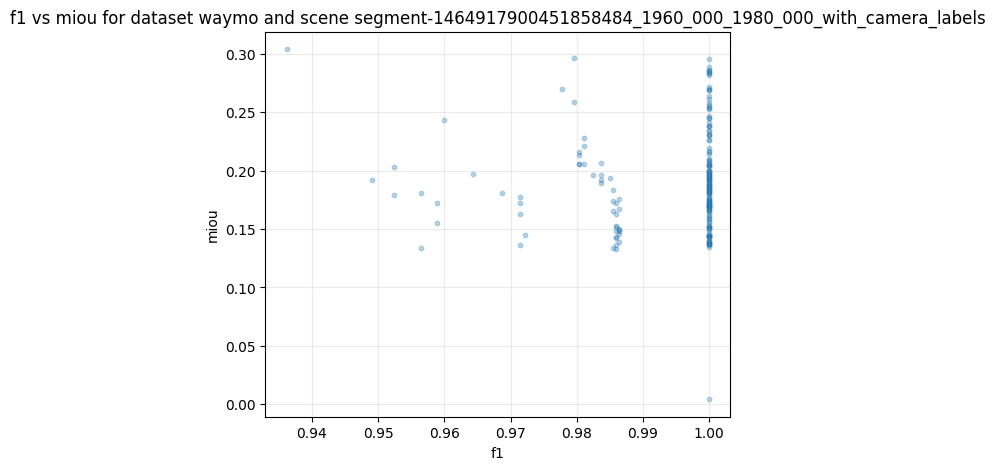

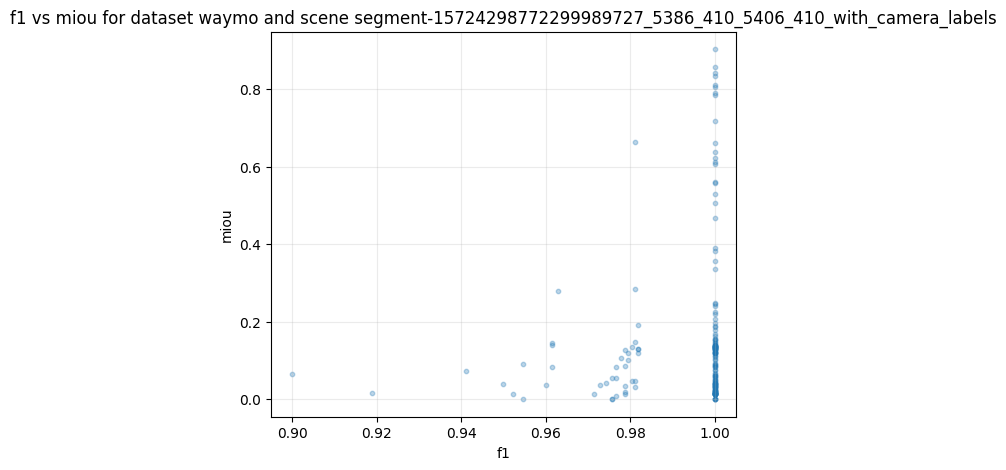

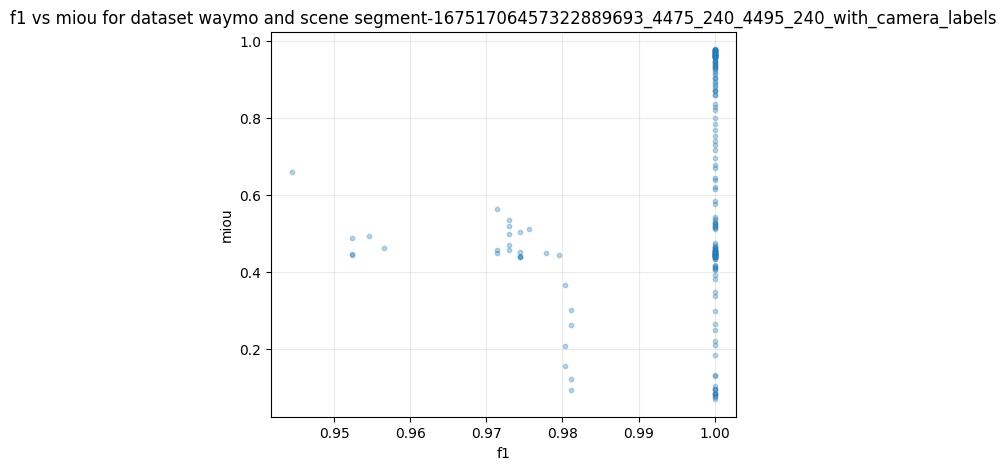

In [9]:
datasets = df["dataset"].unique()
for d in datasets:
    nus_df = df[df['dataset'] == d]
    sc_id = nus_df["scene_id"].unique()
    for s in sc_id:
        nus_df0 = nus_df[nus_df['scene_id'] == s]
        miou = nus_df0['miou']
        f1 = nus_df0['f1']
        plt.figure(figsize=(6,5))
        plt.scatter(f1, miou, s=10, alpha=0.3)
        plt.xlabel("f1")
        plt.ylabel("miou")
        plt.title(f"f1 vs miou for dataset {d} and scene {s}")
        plt.grid(alpha=0.25)
        plt.show()


In [12]:
from pathlib import Path
from analysis.plot_confidence_components import build_score_dataframe, make_plots

df = build_score_dataframe([
    Path("unified_nuscenes_mini.json"),
    Path("unified_nuscenes_full.json"),
    Path("unified_kitti.json"),
    Path("unified_waymo.json"),
])

for w_f1 in [0.2, 0.4, 0.6, 0.8]:
    make_plots(df, Path(f"output/weight_tuning_2wf1_{w_f1:.1f}"), w_f1, 1.0 - w_f1, 1e-6)


In [20]:
df_score = pd.read_csv("/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/predicted_score_distributions/predicted_scores_all.csv")

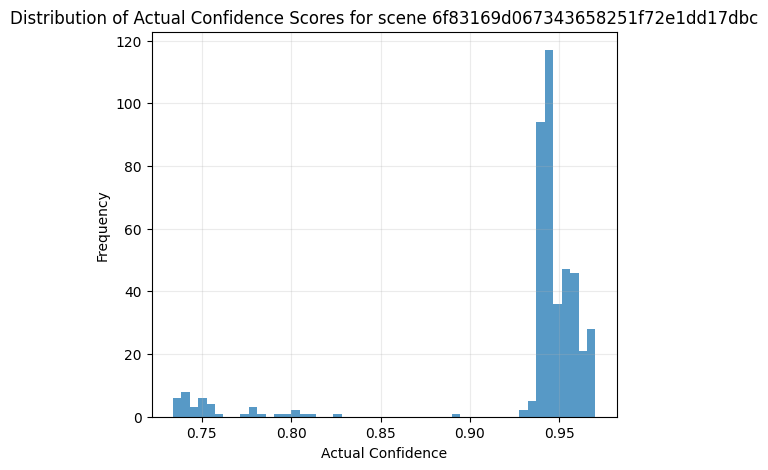

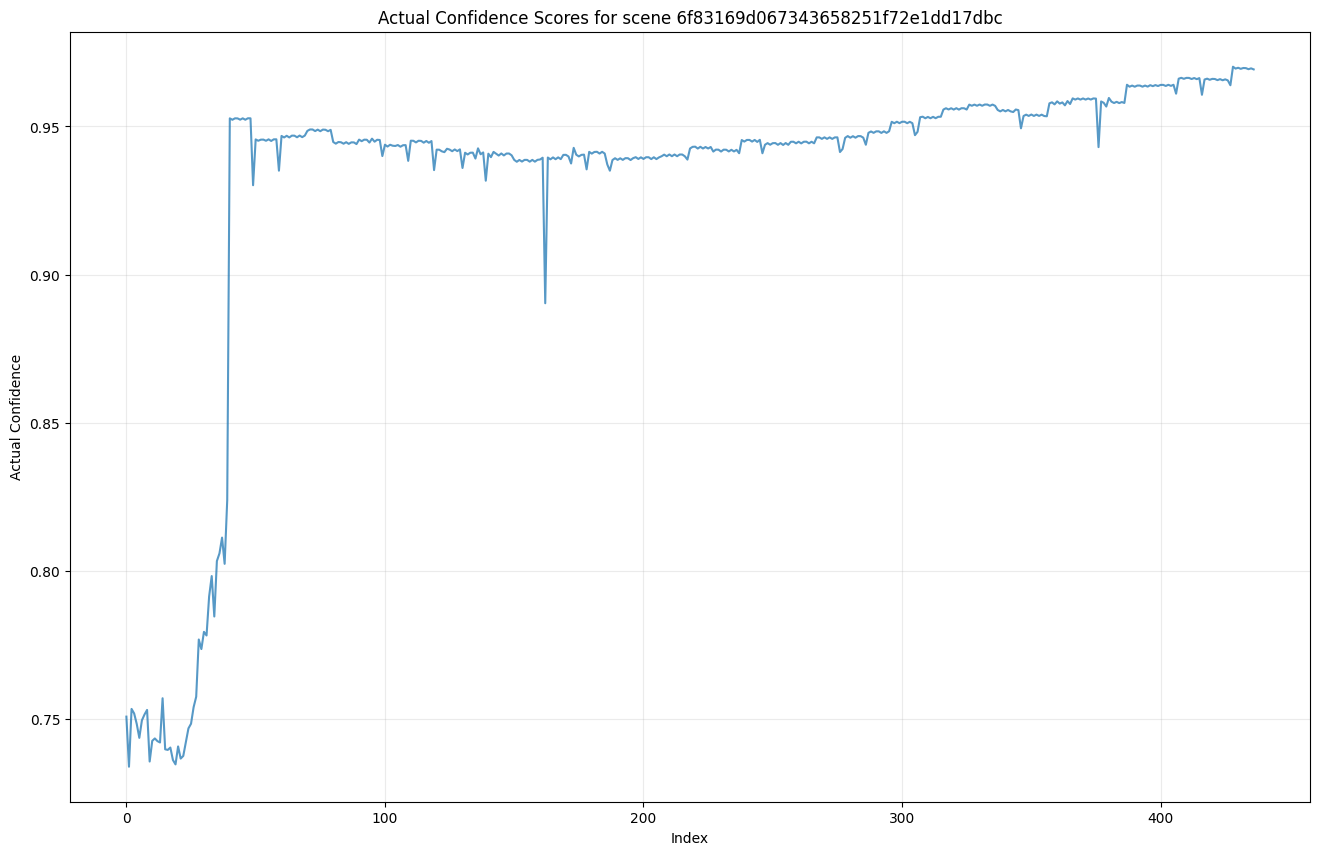

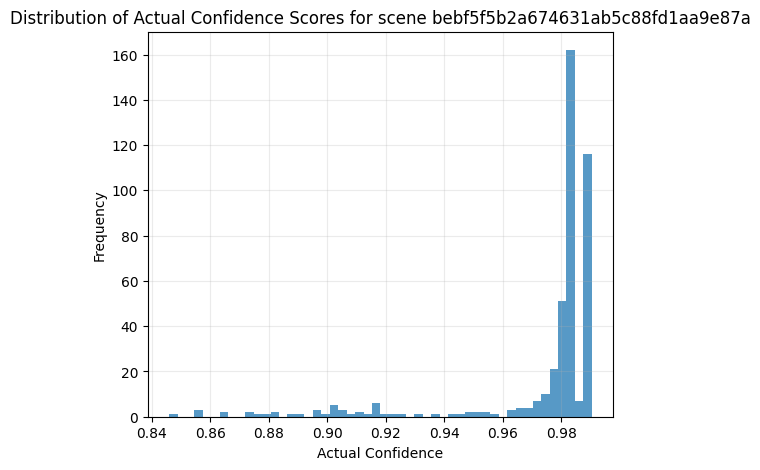

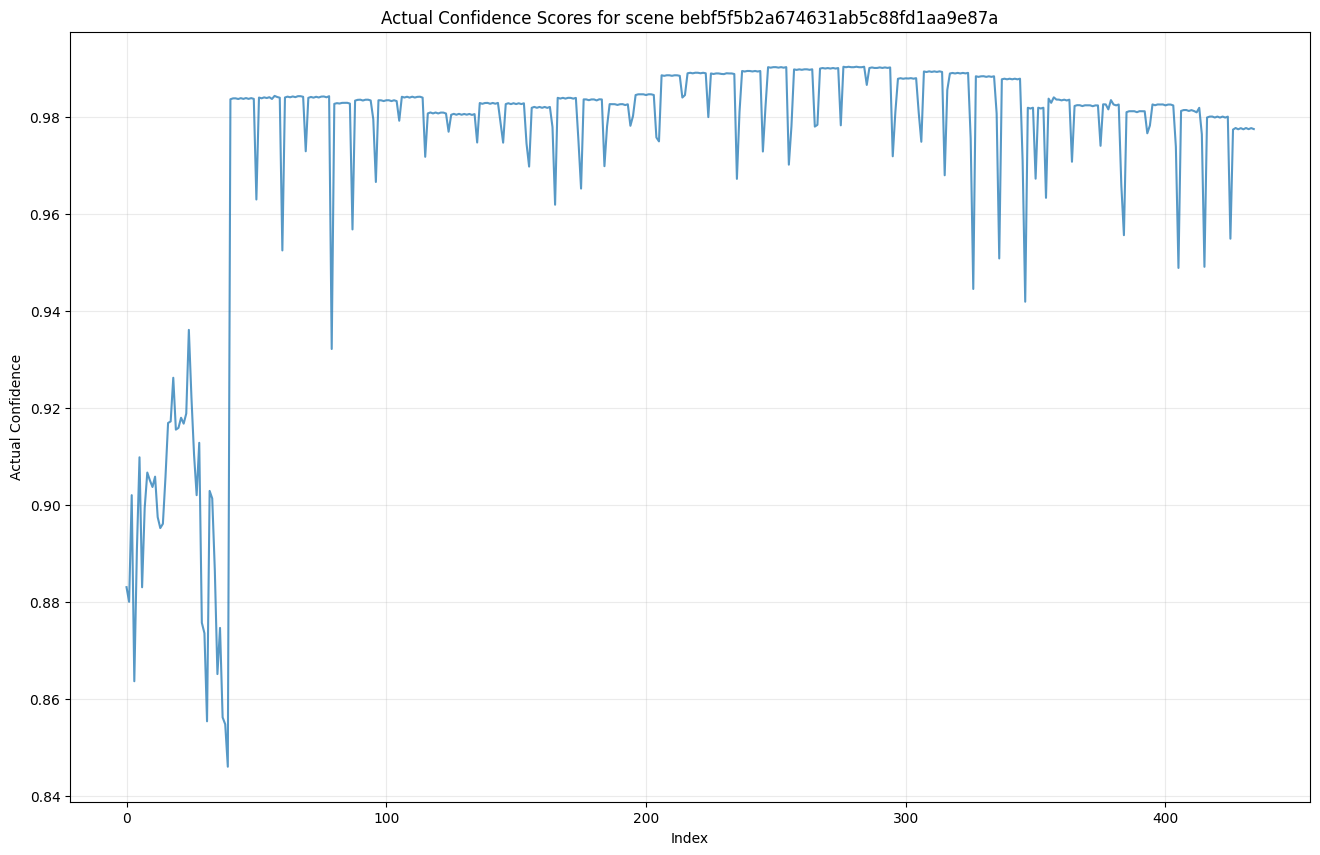

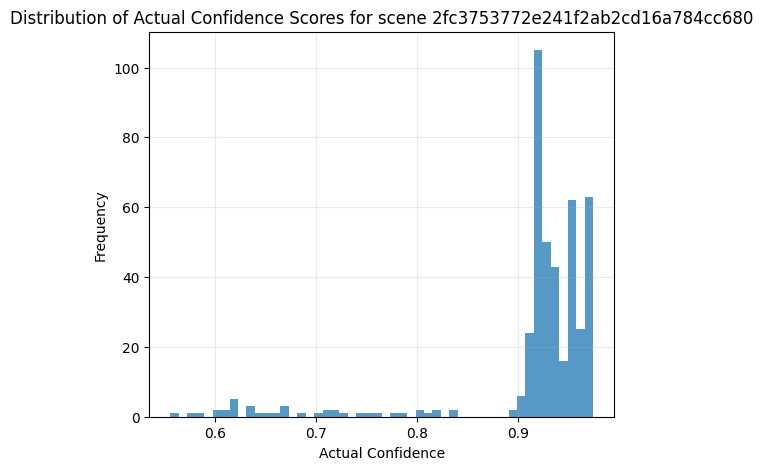

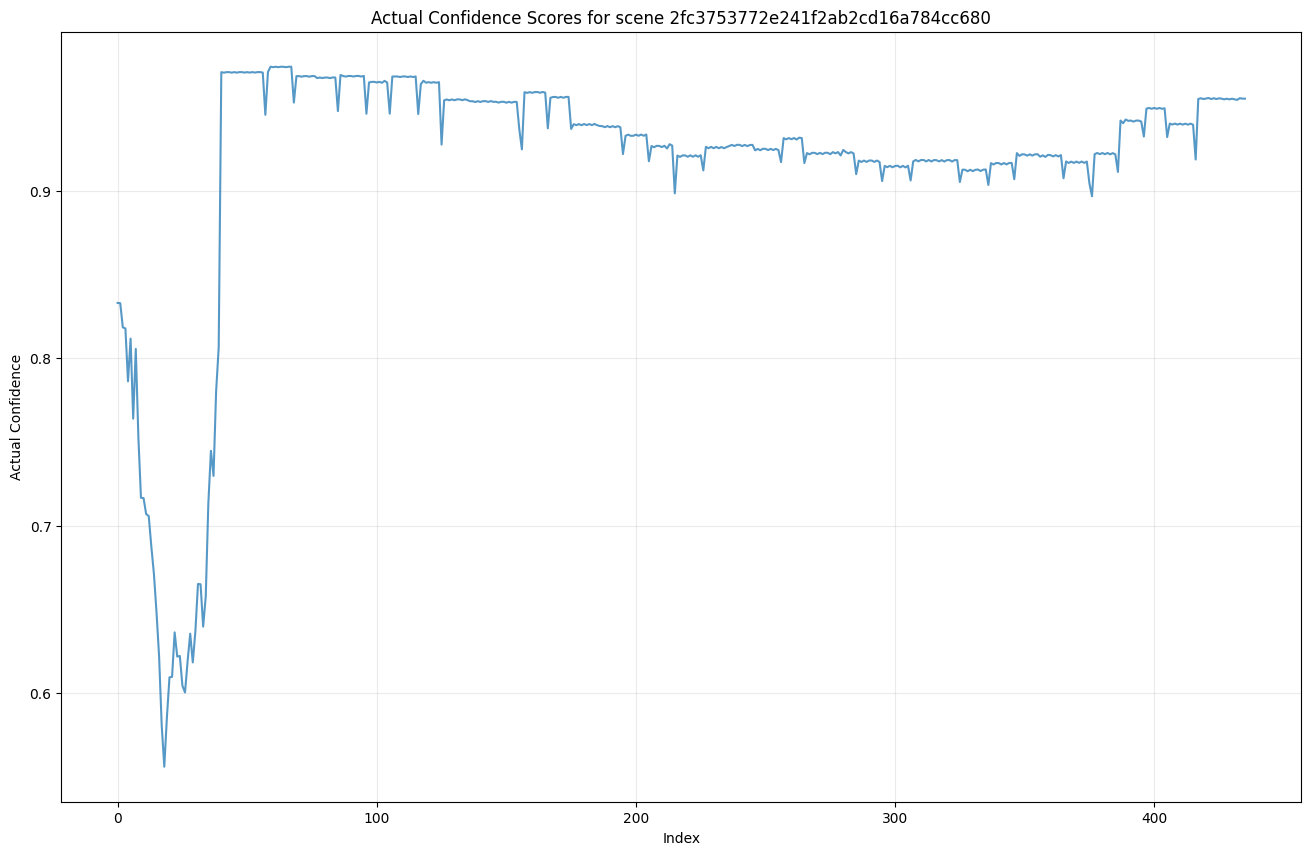

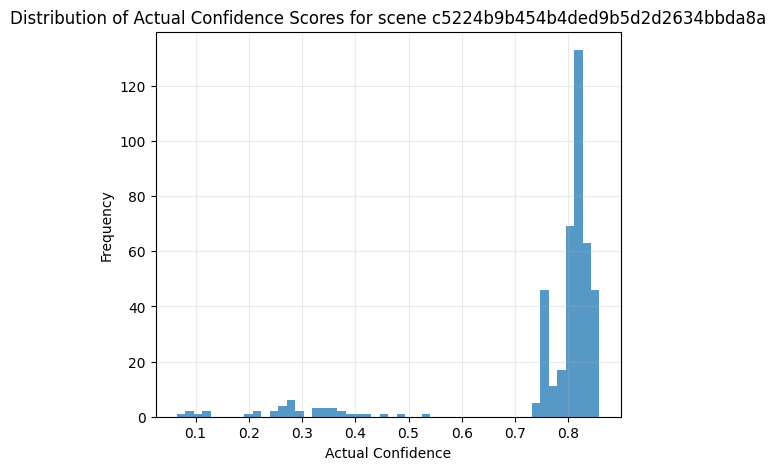

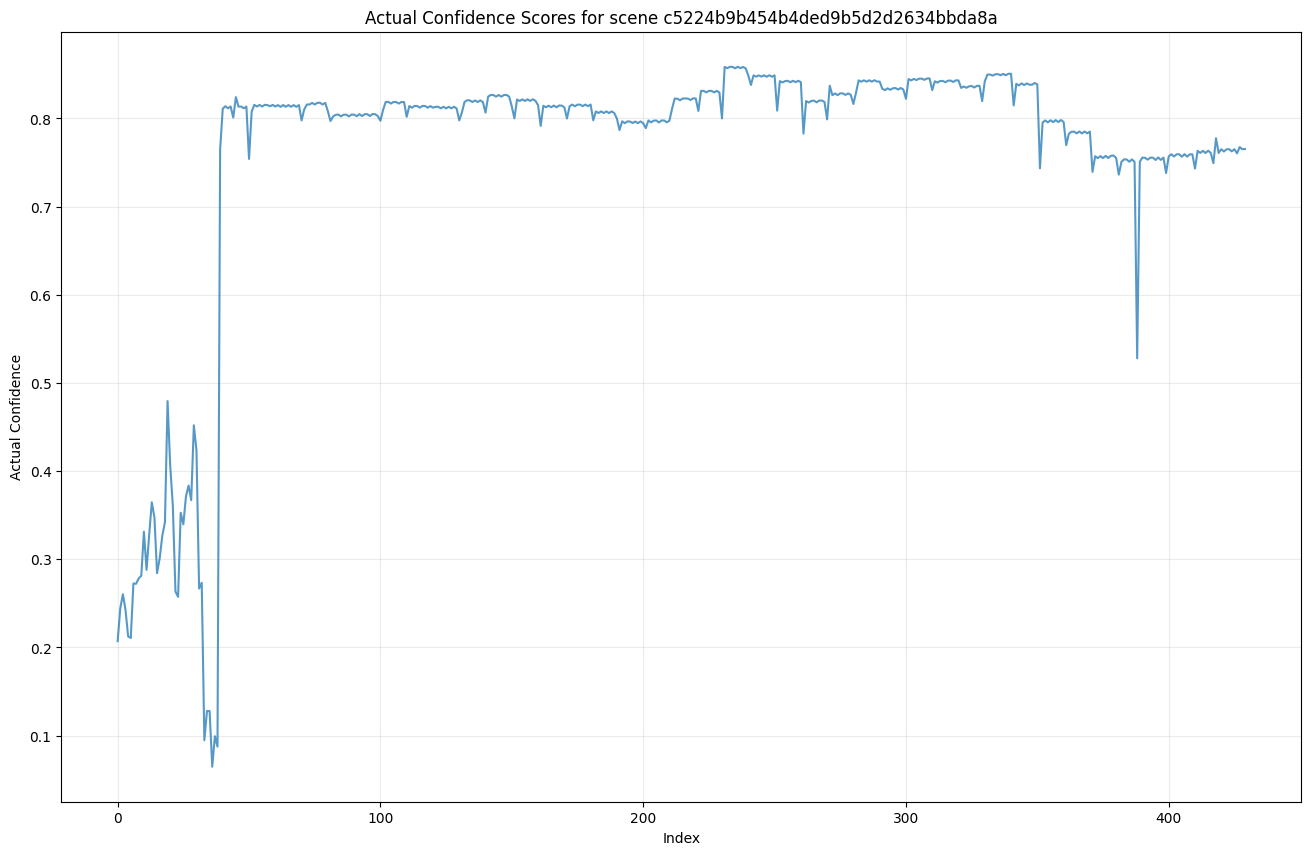

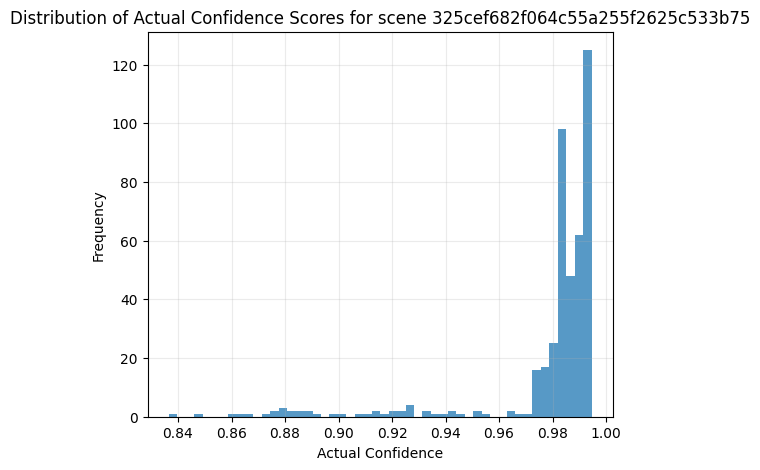

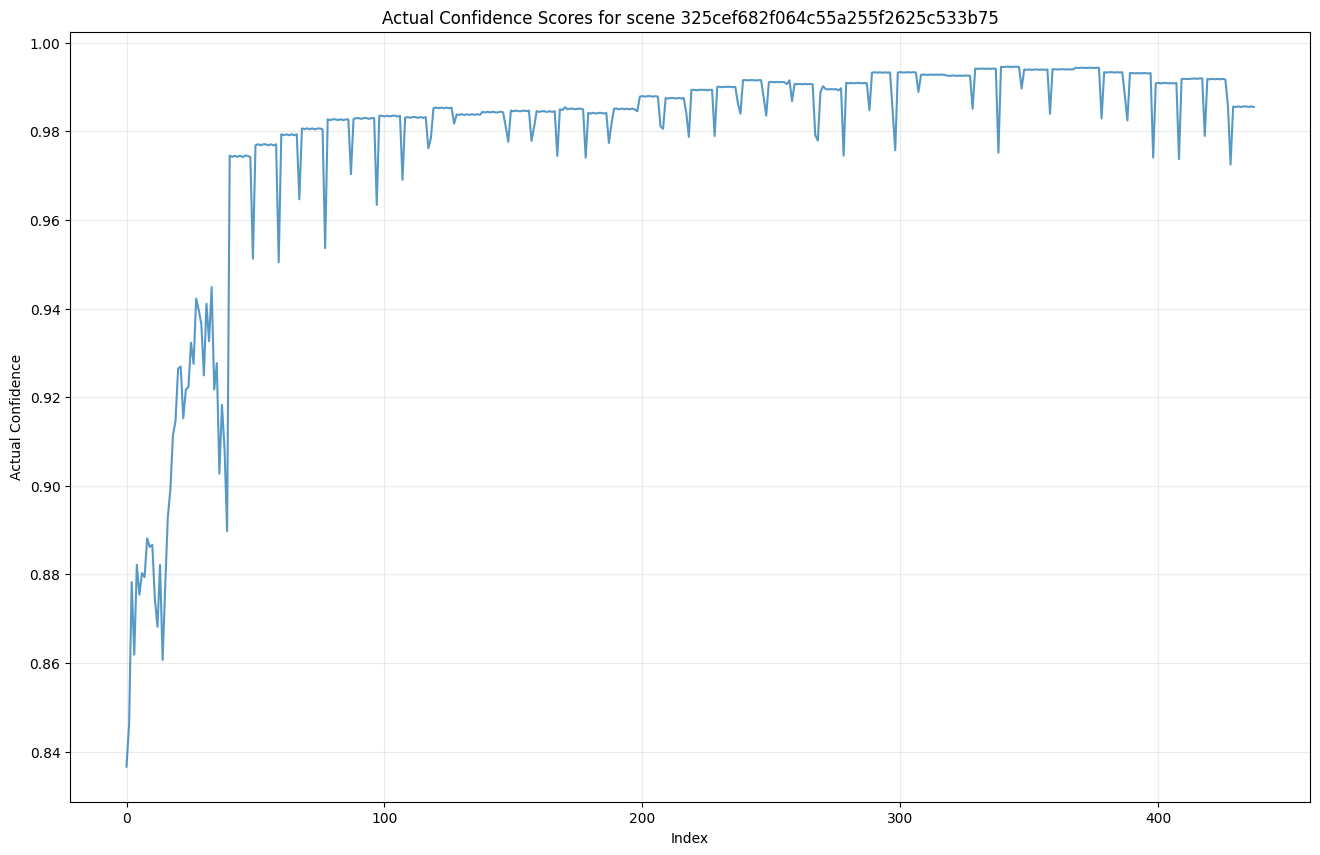

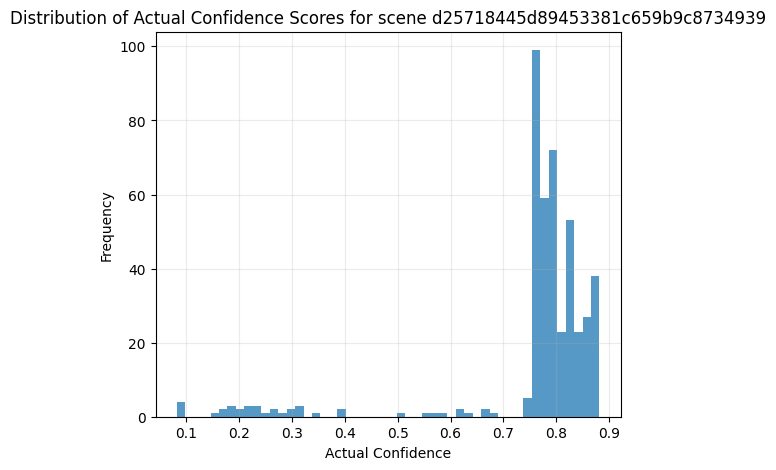

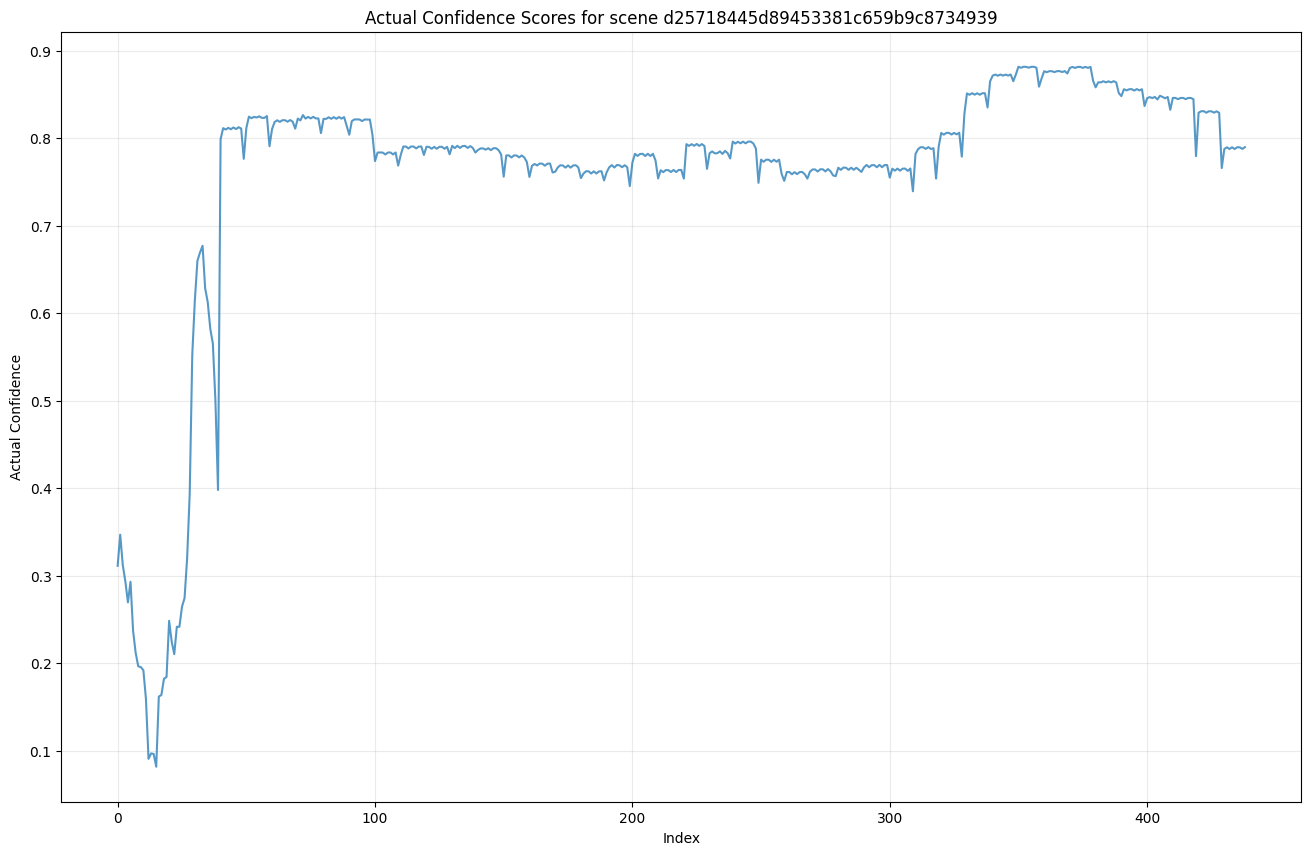

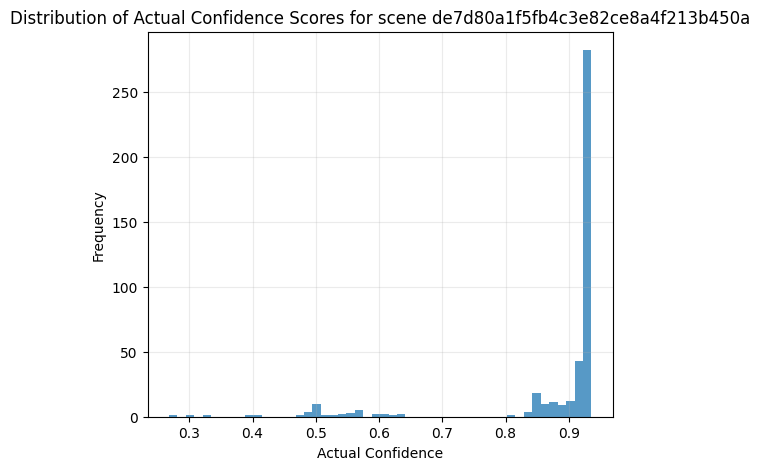

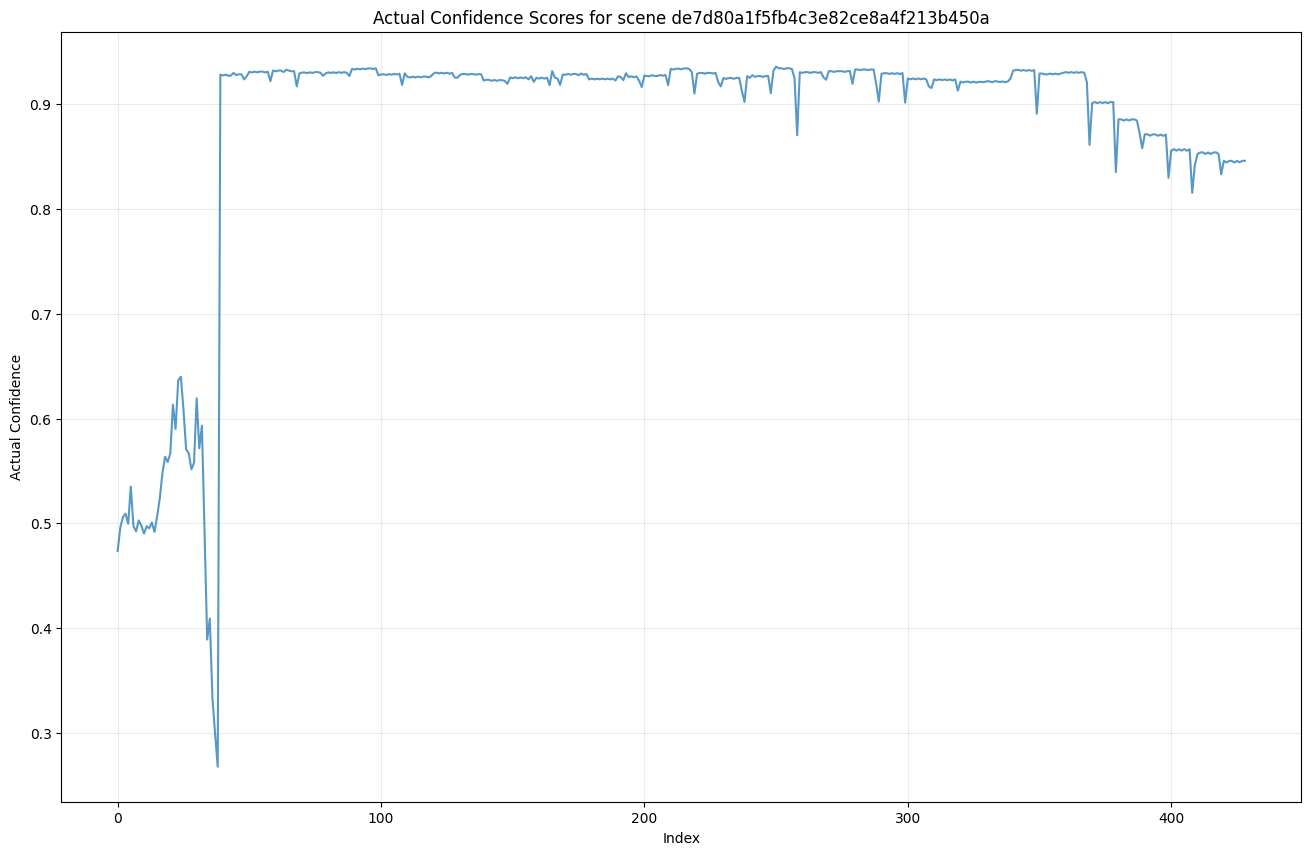

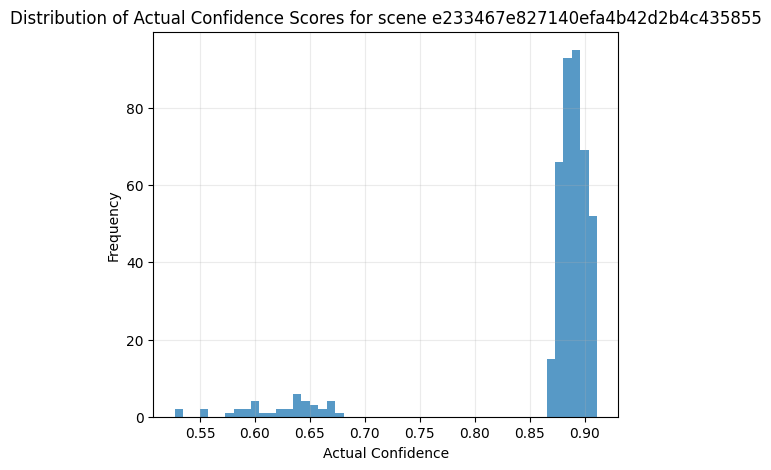

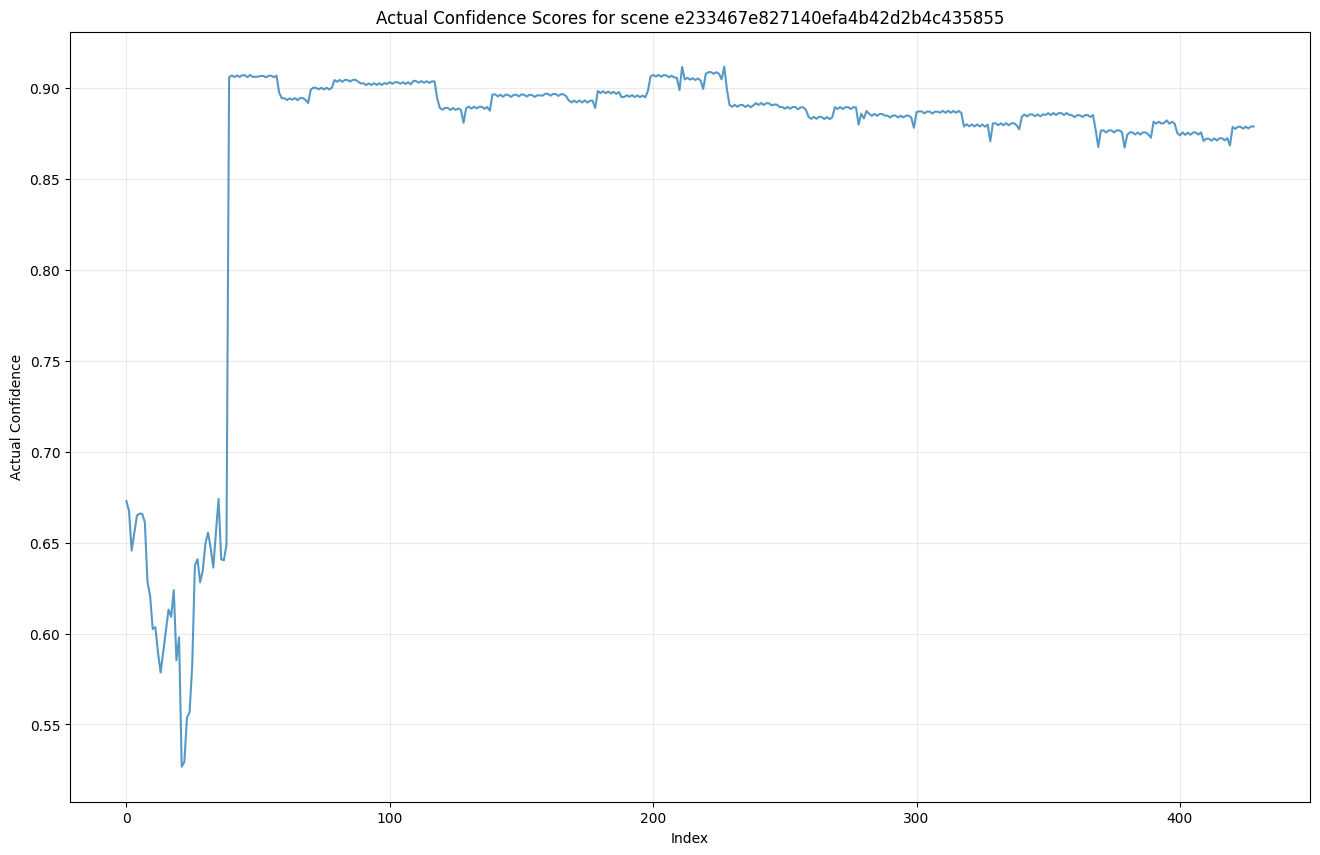

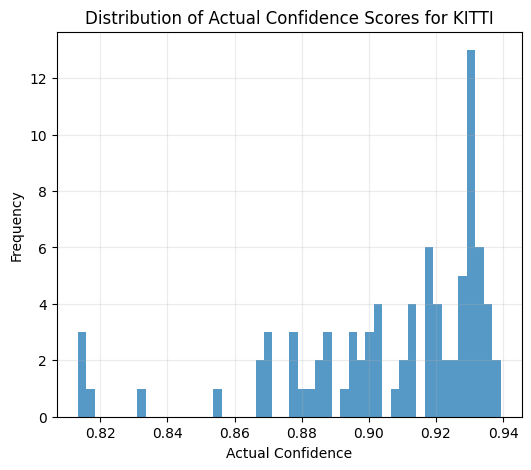

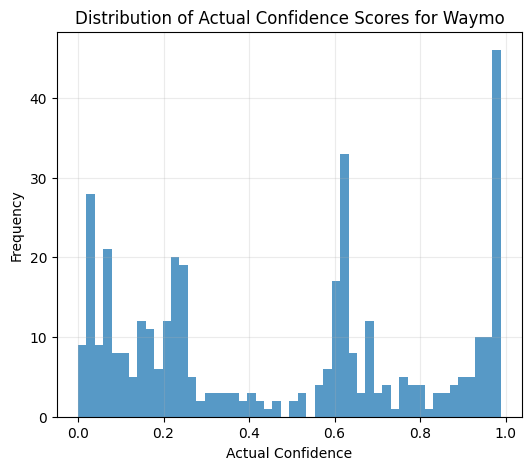

TypeError: unhashable type: 'numpy.ndarray'

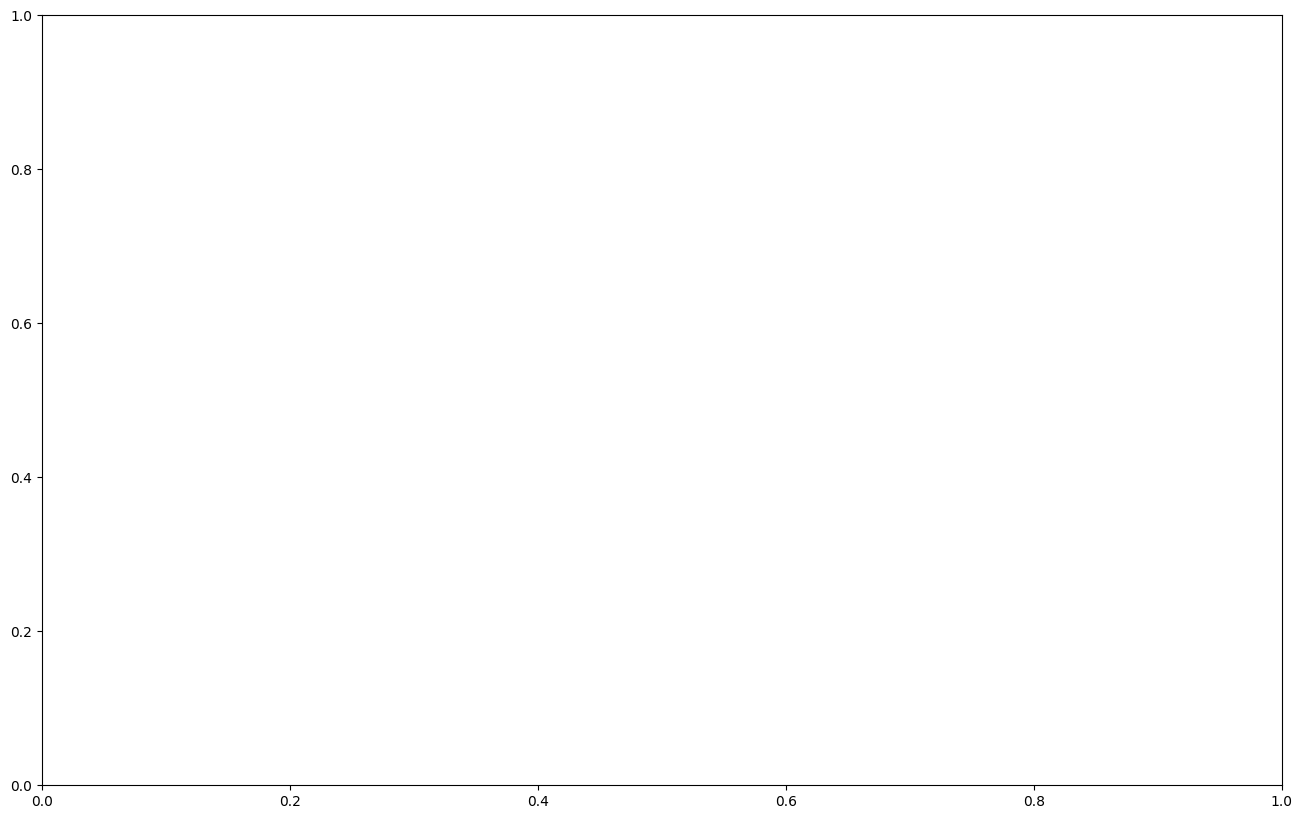

In [29]:
n = df_score[df_score['dataset'] == 'nuscenes_full']
k = df_score[df_score['dataset'] == 'kitti']
w = df_score[df_score['dataset'] == 'waymo']

sc_id = n["scene_id"].unique()

for i in sc_id:
    val = df_score[df_score["scene_id"] == i]["actual_confidence"].values
    plt.figure(figsize=(6,5))
    plt.hist(val, bins=50, alpha=0.75)
    plt.xlabel("Actual Confidence")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Actual Confidence Scores for scene {i}")
    plt.grid(alpha=0.25)
    plt.show()
    
    plt.figure(figsize=(16,10))
    plt.plot(val, alpha=0.75)
    plt.xlabel("Index")
    plt.ylabel("Actual Confidence")
    plt.title(f"Actual Confidence Scores for scene {i}")
    plt.grid(alpha=0.25)
    plt.show()
plt.figure(figsize=(6,5))
plt.hist(k["actual_confidence"].values, bins=50, alpha=0.75)
plt.xlabel("Actual Confidence")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Confidence Scores for KITTI")
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(6,5))
plt.hist(w["actual_confidence"].values, bins=50, alpha=0.75)
plt.xlabel("Actual Confidence")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Confidence Scores for Waymo")
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(16,10))
plt.plot(k, alpha=0.75)
plt.xlabel("Index")
plt.ylabel("Actual Confidence")
plt.title(f"Actual Confidence Scores ")
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(16,10))
plt.plot(w, alpha=0.75)
plt.xlabel("Index")
plt.ylabel("Actual Confidence")
plt.title(f"Actual Confidence Scores ")
plt.grid(alpha=0.25)
plt.show()

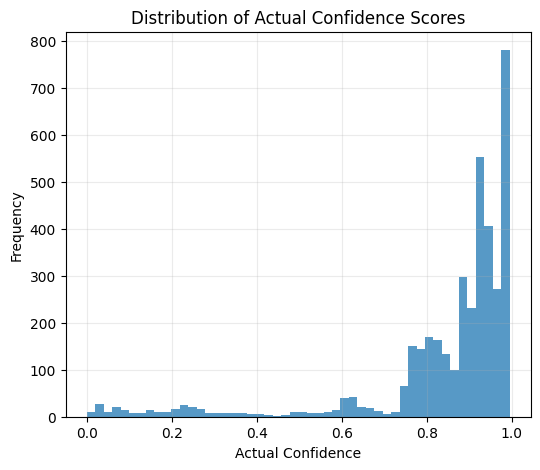

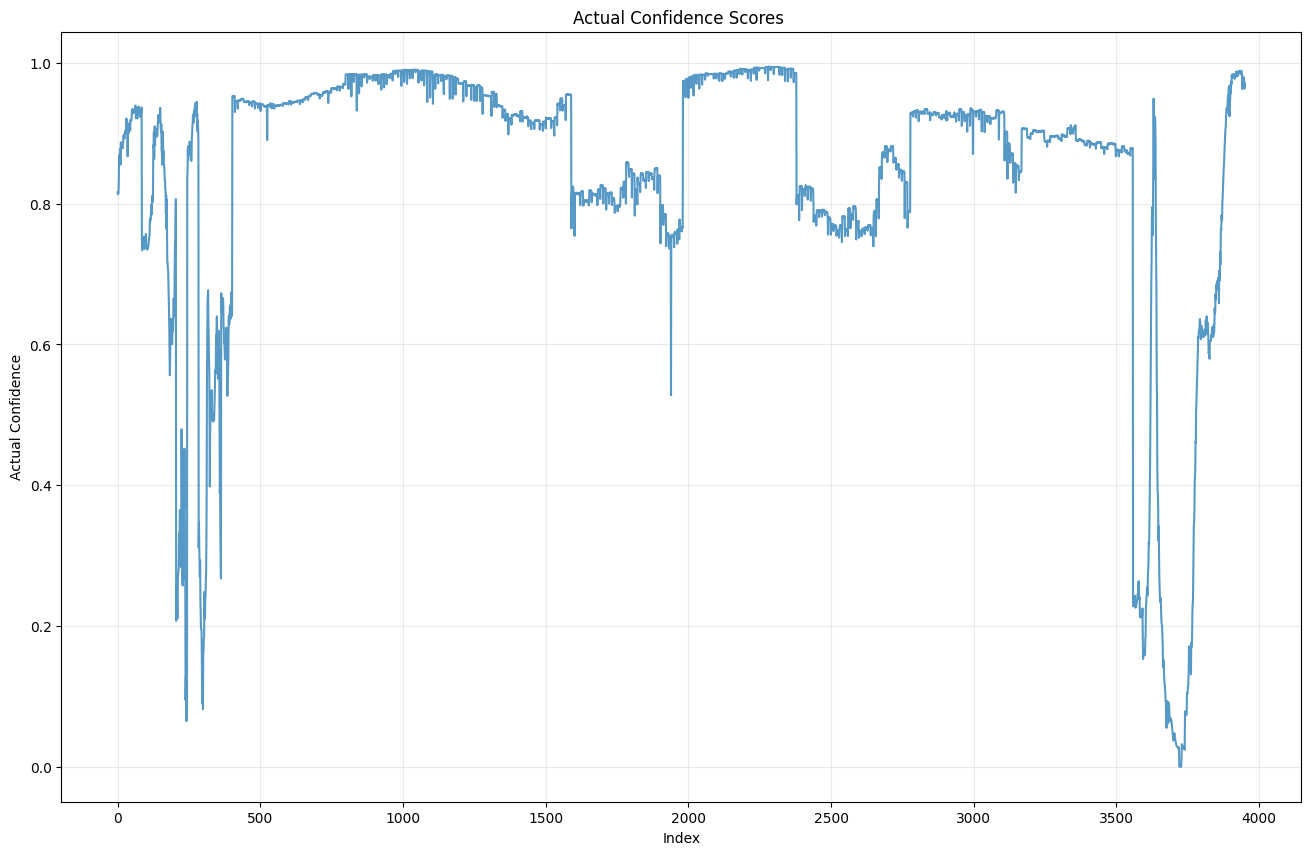

In [28]:
plt.figure(figsize=(6,5))
plt.hist(val, bins=50, alpha=0.75)
plt.xlabel("Actual Confidence")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Confidence Scores")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(16,10))
plt.plot(val, alpha=0.75)
plt.xlabel("Index")
plt.ylabel("Actual Confidence")
plt.title(f"Actual Confidence Scores ")
plt.grid(alpha=0.25)
plt.show()

In [4]:
import json, csv
from pathlib import Path

base = Path("/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/waymo")
json_files = sorted(base.rglob("*_inference.json"))

for jf in json_files:
    data = json.loads(jf.read_text())
    dataset = data.get("dataset", jf.stem.replace("_inference", ""))
    scenes = data.get("scenes", {})
    rows = []

    # Expected schema: scenes = {scene_id: [decision_dict, ...]}
    if isinstance(scenes, dict):
        for scene_id, decisions in scenes.items():
            for d in decisions or []:
                if isinstance(d, dict):
                    row = {"dataset": dataset, "scene_id": scene_id, "source_json": str(jf)}
                    row.update(d)
                    rows.append(row)

    out_csv = jf.with_name(f"{jf.stem}_rows.csv")  # e.g. kitti_inference_rows.csv
    if rows:
        fieldnames = sorted({k for r in rows for k in r.keys()})
        with out_csv.open("w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader()
            w.writerows(rows)
        print(f"Wrote {len(rows)} rows -> {out_csv}")
    else:
        print(f"No rows parsed from {jf}")


Wrote 501 rows -> /media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/waymo/waymo_inference_rows.csv


In [6]:
import pandas as pd

data_paths = [
    "/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/kitti/kitti_inference_rows.csv",
    "/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/nuscenes_full/nuscenes_full_inference_rows.csv",
    "/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/waymo/waymo_inference_rows.csv",
]

dfs = []
for p in data_paths:
    df = pd.read_csv(p)
    if not df.empty:
        print(f"Dataset: {df['dataset'].iloc[0]}, rows: {len(df)}, scenes: {df['scene_id'].nunique()}")
    else:
        print(f"Empty file: {p}")
    dfs.append(df)

# Outer concat (keeps all columns from all files)
all_df = pd.concat(dfs, ignore_index=True, sort=False)

out_csv = "/media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/all_inference_rows.csv"
all_df.to_csv(out_csv, index=False)

print(f"Saved {len(all_df)} rows to {out_csv}")


Dataset: kitti, rows: 448, scenes: 2
Dataset: nuscenes_full, rows: 3337, scenes: 9
Dataset: waymo, rows: 501, scenes: 3
Saved 4286 rows to /media/tersiteab/new_drive/checker_model/Point-Cloud-Similarity-Score/output/all_inference_rows.csv


In [ ]:
for p in data__paths:
    df = pd.read_csv(p)
    print(f"Dataset: {df['dataset'].iloc[0]}, Scene IDs: {df['scene_id'].unique()}")
    